In [132]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display, Markdown
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import *
from scipy import constants as const 
from uncertainties.umath import atan, degrees
import math
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator

# PW10 - Thermodynamik

$$\text{Anna Lechner, Paula Erhard}$$

## Wärmekapazität und spezifische Wärme

### Versuchsaufbau und Durchführung

In einem Dewar werden ca. 200g Wasser erhitzt, um den Temperaturanstieg aufzunehmen und daraus die Wärmekapazität zu bestimmen. Dazu wird der Deckel mit Heizelementen verwendet. Die Temperaturaufzeichnung erfolgt mit einem Thermoelement und wird computergestützt durchgeführt. Um die Anfangswerte zu kontrollieren, wird die Aufzeichnung einige Minuten vor Beginn des Heizprozesses gestartet. Nach 10 min wird die Heizung abgeschalten, wobei die Aufzeichnung der Temperatur danach noch für einige Minuten weiter gelaufen lassen wird. 

Außerdem wird zu Beginn und Ende des Heizprozesses Stromstärke und Spannung am Heizelement notiert, um so über die elektrische Leistung die zugeführte Energie zu bestimmen. Daraus, aus der linearen Steigung der Temperaturzunahme und der bekannten Wärmekapazität lässt sich die Wärmekapazität ermitteln.

### Wichtige Formeln und Zusammenhänge

Wärmekapazität C:
$$\Delta Q = C \Delta T$$

Spezifische Wärme c:
$$\Delta Q = c m \Delta T$$

Ermittlung Wärmekapazität Wasser:
$$C_w = \frac{UI}{b} - C_k$$
wobei b der lineare Anstieg der Temperatur über die Zeit ist.

### Verwendete Geräte und Unsicherheiten

* Kalirometer:  $C_k = 135 \pm 10 ~ \mathrm J/K$
* UT61B Thermoelement: Unsicherheit (1,2% + 3 Digit)
* UT61B Voltmeter: Auflösung 0,01V; Unsicherheit (1,0% + 3 Digit)
* UT61B Amperemeter: Auflösung 0,01A; Unsicherheit (2,0% + 5 Digit)

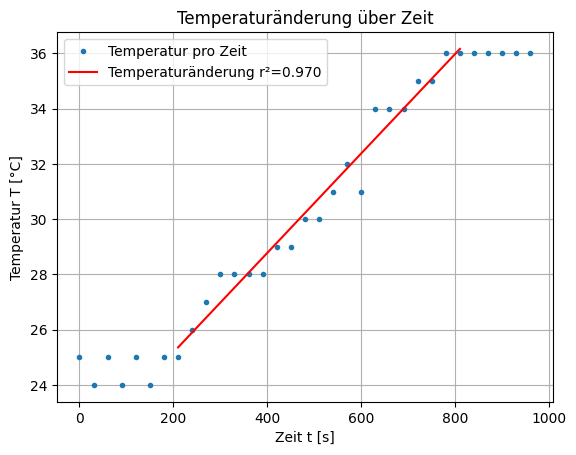

Die Steigung der linearen Regressionsfuktion ist: 0.0180+/-0.0007

$$P = (17.32+/-0.50) ~ \mathrm{\frac{J}{s}}$$

$$C_W = (826.61+/-48.88) ~ \mathrm{\frac{J}{K}}$$

$$c_W = (4.13+/-0.24) ~ \mathrm{\frac{kJ}{K \cdot kg}}$$

In [133]:
# Experiment 1: Wärmekapazität und spezifische 


m_w = 0.449 - 0.249        #Masse Wasser [kg]
C_k = ufloat(135, 10)       #Wärmekapazität Kalorimeter [J/K]


T0 =  25                                  #Anfangstemperatur [°C]
uT0 = ufloat(T0, (T0 * 0.012) + 3)

U0 =  6.12                                  #Anfangspannung [V]
uU0 = ufloat(U0, (U0 * 0.01) + 0.03)
I0 =  2.805                                  #Anfansstrom [A]
uI0 = ufloat(I0, (I0 * 0.02) + 0.05)

U_t = 6.14                                  #Endspannung [V]
uU_t = ufloat(U_t, (U_t * 0.01) + 0.03)
I_t = 2.845                                  #Endsstrom [A]
uI_t = ufloat(I_t, (I_t * 0.02) + 0.05)


df = pd.read_csv("Wärmekapazität.csv", sep=',', decimal='.', engine='python')         #Werte kommen aus .csv Datei
t = df["Time since start of measurement"].to_numpy()                         #Zeit aus csv
temp = df["temp"].to_numpy()                      #Temperatur aus csv

t1 = t[7:28]
temp1 = temp[7:28]

P = ((uU0+uU_t)/2) * ((uI0+uI_t)/2)            #durchschnittliche Leistung (evtl nicht nötig wenn Anfangs und Endwerte gleich)

slope, intercept, r, _, std, = linregress(t1, temp1)           #lineare Regression für Temperaturanstieg; Werte einschränken, so dass nur lin Teil bleibt!!

b = ufloat(slope, std)          #Steigung mit Fehler aus lin. Reg.


C_w = (P/b) - C_k           #Wärmekapazität Wasser [J/K]

c = (C_w/m_w) * 10**(-3)                #spezifische Wärme Wassr [J/(K*kg)]



#plot und Werte ausgeben
plt.figure()
plt.plot(t, temp, 'o', markersize=3, label=rf"Temperatur pro Zeit")
plt.plot(t1, (t1*slope)+intercept, '-r', label=rf"Temperaturänderung r²={r**2:.3f}")
plt.xlabel("Zeit t [s]")
plt.ylabel("Temperatur T [°C]")
plt.title("Temperaturänderung über Zeit")
plt.legend()
plt.grid(True)
plt.show()

display(Markdown(rf"Die Steigung der linearen Regressionsfuktion ist: {b}"))

display(Markdown(rf"$$P = ({P:.2f}) ~ \mathrm{{\frac{{J}}{{s}}}}$$"))               #Leistung
display(Markdown(rf"$$C_W = ({C_w:.2f}) ~ \mathrm{{\frac{{J}}{{K}}}}$$"))           #Wärmekapazität
display(Markdown(rf"$$c_W = ({c:.2f}) ~ \mathrm{{\frac{{kJ}}{{K \cdot kg}}}}$$"))    #spezifische Wärme




### Diskussion

Die Wärmekapazität beträgt ca. 827 J/K und die spezifische Wärme von Wasser liegt bei ca. 4.13 kJ/(K * kg). Dies kommt dem wahren Wert von 4.19 kJ/(K * kg) sehr nahe und es kann von Übereinstimmung ausgegangen werden.

## Schmelzwärme von Eis

### Versuchsaufbau und Durchführung

In einen Dewar wird 70 °C heißes Wasser eingefüllt und die Temperaturaufzeichnung gestartet. Nach drei Minuten wird 20g - 50g Eis hinzugegeben, welches idealerweise eine Temperatur von 0°C hat. Dabei ist wichtig, daruaf zu achten, dass das Thermoelement nie aus dem Wasser genommen wird. Die Gesamtmasse von Wassser und Eis sollte nicht mehr als 220g sein. Wenn sich alles Eis aufgelöst hat wird noch einige Minute weiter die Temperatur aufgezeichnet. 

Aus dem aufgezeichneten Temperaturverlauf werden durch Extrapolation die Temperaturen $T_1$ und $T_m$ bestimmt, indem bei dem rasanten Temperaturabstieg eine vertikale Linie durchgelegt wird, so dass die eingeschlossenen Flächen ca. gleich groß sind. So lässt sich die Spezifische Schmelzwärme berechnen.

### Wichtige Formeln und Zusammenhänge

spezifische Schmelzwärme:
$$S = \frac{Q_S}{m}$$

abgegebene Wärme:
$$\Delta Q_1 = (C_k + m_w c_w)(T_1 - T_m)$$

aufgenommene Wärme:
$$\Delta Q_2 = m_e S + m_e c_w (T_m - T_S)$$

### Verwendete Geräte und Unsicherheiten 

* Kalirometer:  $C_k = 100 \pm 10 ~ \mathrm J/K$
* UT61B Thermoelement: Unsicherheit (1,2% + 3 Digit)

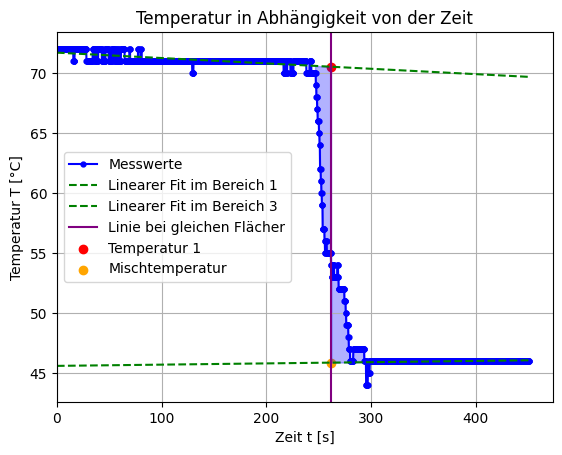

$$S = 308+/-14 ~ \mathrm J/g$$

In [134]:
# Experiment 2: Schmelzwärme von Eis

me = ufloat(36.8, 1)# masse eis
mw = ufloat(178, 1)  # masse wasser
Ck = ufloat(100, 10) # wärmekapazität kalorimeter in J/K
cw = float(4.19*10**3) # spezifische Wärem Wasser, in J/kg*K


df = pd.read_csv("schmlezwärme_1212.csv", sep=',', decimal='.', engine='python')
T = df["temp"].to_numpy()
t = df["Time since start of measurement"].to_numpy()

# fits 
I = 986            #index aus csv datei suchen
II = 1182

t0 = 262 # beispielwert zum ausprobieren; schätzen und ausprobieren, Zeit für vertikale linie

# abschnitt 1
x1 = t[0:I]
y1 = T[0:I]

res1 = linregress(x1, y1)

y1_fit = res1.slope*t + res1.intercept

x1_plot = t 
y1_plot = y1_fit 
T_1 = ufloat(res1.slope*t0 + res1.intercept, 0.018)


# abschnitt 3
x3 = t[II:]
y3 = T[II:]

res3 = linregress(x3, y3) 
y3_fit = res3.slope*t + res3.intercept
x3_plot = t 
y3_plot = y3_fit
T_m = ufloat(res3.slope*t0 + res3.intercept, 0.004)

T_S = 0             #weil eis bei 0°C schmilzt

#Ich nenne hier die Anfangstemperatur T_1 (Fit von I ausgewertet bei t0) und die Mischtemperatur T_m (Fit von III ausgewertet bei t0), die Schmelztemperatur T_S ist 0 (nicht sicher, deswegen lasse ich es mal)

S = (((Ck + mw * cw) * (T_1 - T_m) - me * cw * (T_m - T_S))/me) *10**(-3)# hier ev T_1 und T_m ändern mit _ danach für eigene Unsicherheiten
S_nom = S.nominal_value

# plot
plt.figure()
plt.plot(t, T, marker='o', markersize=3.5, label="Messwerte", color='blue')
plt.plot(x1_plot, y1_plot, "--", label=f"Linearer Fit im Bereich 1", color='green')
plt.plot(x3_plot, y3_plot, "--", label=f"Linearer Fit im Bereich 3", color='green')
plt.axvline(t0, linestyle="-", label="Linie bei gleichen Flächer", color='purple') # einsetzen!!
plt.xlabel("Zeit t [s]")
plt.scatter(t0, unp.nominal_values(T_1), marker="o", color='red', label="Temperatur 1")
plt.scatter(t0, unp.nominal_values(T_m), marker="o", color='orange', label="Mischtemperatur")
#plt.scatter(t0, S_nom, marker="o", color='red', label="Spezifische Schmelzwärme")
plt.fill_between(t[I:II], T[I:II], y1_plot[I:II], where=(t[I:II] <= t0), alpha=0.3, color='blue')
plt.fill_between(t[I:II], T[I:II], y3_plot[I:II], where=(t[I:II] >= t0), alpha=0.3, color='blue')
plt.ylabel("Temperatur T [°C]")
plt.title("Temperatur in Abhängigkeit von der Zeit")
plt.xlim(left=0)
plt.legend()
plt.grid(True)
plt.show()


#print(f"Die Schmelzwärme beträgt {S} J/kg")
display(Markdown(rf"$$S = {S} ~ \mathrm J/g$$"))




    



### Diskussion

Der errechnete Wert von 308 J/g kommt dem wahren Wert von 335 J/g (https://www.leifiphysik.de/waermelehre/innere-energie-waermekapazitaet/versuche/schmelzwaerme-von-eis, 12.12.2025) sehr nahe und es kann von Übereinstimmung ausgegangen werden.

Die Unsicherheit wurde abgeschätzt durch die Werte von $T_m$ unfd $T_1$ eine Sekunde vor und nach dem optischen Schätzwert der gleichen Flächen.